# 0. Download dataset & Import libraries

In [1]:
import torch
import torch.nn as nn
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path

def set_seed(seed=42):
	random.seed(seed)
	os.environ['PYTHONHASHSEED'] = str(seed)
	np.random.seed(seed)

	torch.manual_seed(seed)

	if torch.backends.mps.is_available():
		torch.mps.manual_seed(seed)
		os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

	if torch.cuda.is_available():
		torch.cuda.manual_seed(seed)
		torch.cuda.manual_seed_all(seed)
		torch.backends.cudnn.deterministic = True
		torch.backends.cudnn.benchmark = False

	try:
		torch.use_deterministic_algorithms(True)
	except RuntimeError:
		pass

In [2]:
!pip install seqeval -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [3]:
from datasets import load_dataset

ds = load_dataset("thainq107/abte-restaurants")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/454 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/183k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/61.8k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3602 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1119 [00:00<?, ? examples/s]

In [4]:
ds

DatasetDict({
    train: Dataset({
        features: ['Tokens', 'Tags', 'Polarities'],
        num_rows: 3602
    })
    test: Dataset({
        features: ['Tokens', 'Tags', 'Polarities'],
        num_rows: 1119
    })
})

In [5]:
id2label = {
    0: "O",
    1: "B-Term",
    2: "I-Term"
}
label2id = {
    "O": 0,
    "B-Term": 1,
    "I-Term": 2
}

# 2. Evaluation

In [6]:
from seqeval.metrics import accuracy_score, f1_score

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)
    true_predictions = [
        [id2label[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [id2label[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    results = f1_score(true_predictions, true_labels)
    return {"F1-score": results}

In [7]:

def save_local_checkpoint(model, model_name, base_dir='./saved_models', tokenizer=None):
    """Save model locally for later inference without pushing to Hub."""
    save_dir = Path(base_dir) / model_name
    save_dir.mkdir(parents=True, exist_ok=True)

    # Hugging Face models (e.g., DistilBERT)
    if hasattr(model, 'save_pretrained'):
        model.save_pretrained(save_dir)
        if tokenizer is not None and hasattr(tokenizer, 'save_pretrained'):
            tokenizer.save_pretrained(save_dir)
        print(f'Saved Hugging Face model to: {save_dir.resolve()}')
        return str(save_dir)

    # PyTorch custom models (RNN/LSTM/GRU/BiLSTM...)
    torch.save(model.state_dict(), save_dir / 'model_state_dict.pt')
    print(f'Saved PyTorch state_dict to: {(save_dir / "model_state_dict.pt").resolve()}')
    return str(save_dir)

# 3. LSTM

## 3.1. Tokenizer

In [8]:
corpus = [" ".join(i) for i in ds['train']['Tokens']]

In [9]:
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, processors
from transformers import PreTrainedTokenizerFast, AutoTokenizer

tokenizer_dir = './restaurant_word_tokenizer'
os.makedirs(tokenizer_dir, exist_ok=True)

tokenizer = Tokenizer(models.WordLevel(unk_token="<unk>"))
tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()
trainer = trainers.WordLevelTrainer(
    vocab_size=5000,
    special_tokens=["<pad>", "<unk>"]
)

tokenizer.train_from_iterator(corpus, trainer)
tokenizer.save(f'{tokenizer_dir}/tokenizer.json')

hf_fast_tokenizer = PreTrainedTokenizerFast(
    tokenizer_file=f'{tokenizer_dir}/tokenizer.json',
    unk_token='<unk>',
    pad_token='<pad>'
)
hf_fast_tokenizer.save_pretrained(tokenizer_dir)

tokenizer = AutoTokenizer.from_pretrained(tokenizer_dir, use_fast=True)
vocab_size = tokenizer.vocab_size
pad_token_id = tokenizer.pad_token_id

In [10]:
vocab_size

4286

In [11]:
MAX_LEN = max([len(tokens) for tokens in ds['train']['Tags']])
MAX_LEN

79

In [12]:
def tokenize_and_align_labels(examples):
    tokenized = tokenizer(
        examples["Tokens"],
        is_split_into_words=True,
        padding='max_length',
        truncation=True,
        max_length=MAX_LEN
    )

    labels = []

    for i, tags in enumerate(examples["Tags"]):
        word_ids = tokenized.word_ids(batch_index=i)
        label_ids = []

        for word_id in word_ids:
            if word_id is None:
                label_ids.append(-100)
            else:
                label_ids.append(int(tags[word_id]))

        labels.append(label_ids)

    tokenized["labels"] = labels
    return tokenized

In [13]:
preprocessed_ds = ds.map(tokenize_and_align_labels, batched=True)

Map:   0%|          | 0/3602 [00:00<?, ? examples/s]

Map:   0%|          | 0/1119 [00:00<?, ? examples/s]

## 3.2. Model

In [14]:
class ABTELSTMClassifier(nn.Module):
    def __init__(self, vocab_size, num_classes,
                 embedding_dim=256, hidden_dim=256, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(
            vocab_size, embedding_dim, padding_idx=pad_idx
        )
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, bidirectional=True, batch_first=True)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
        self.loss_fn = nn.CrossEntropyLoss()

    def forward(self, input_ids, labels=None, **kwargs):
        embedded = self.embedding(input_ids)
        outputs, _ = self.lstm(embedded)

        logits = self.fc(outputs)

        loss = None
        if labels is not None:
            loss = self.loss_fn(logits.permute(0, 2, 1), labels)

        return {"loss": loss, "logits": logits}

model = ABTELSTMClassifier(len(tokenizer.get_vocab()), num_classes=3, pad_idx=pad_token_id)

## 3.3 Training

In [15]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir="abte-restaurants-rnn",
    logging_dir="logs",
    learning_rate=2e-5,
    per_device_train_batch_size=256,
    per_device_eval_batch_size=256,
    num_train_epochs=100,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="F1-score",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=preprocessed_ds["train"],
    eval_dataset=preprocessed_ds["test"],
    compute_metrics=compute_metrics,
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [16]:
trainer_results = trainer.train()
save_local_checkpoint(model, 'lstm_model')

Epoch,Training Loss,Validation Loss,F1-score
1,1.025251,1.015540,0.106927
2,0.992381,0.985424,0.081311
3,0.961555,0.955899,0.057471
4,0.930494,0.926456,0.041896
5,0.899546,0.896578,0.040257
6,0.868030,0.865911,0.039538
7,0.834066,0.834271,0.037290
8,0.797473,0.801372,0.029206
9,0.764174,0.767371,0.021872
10,0.722974,0.732673,0.016911


Saved PyTorch state_dict to: /content/saved_models/lstm_model/model_state_dict.pt


'saved_models/lstm_model'

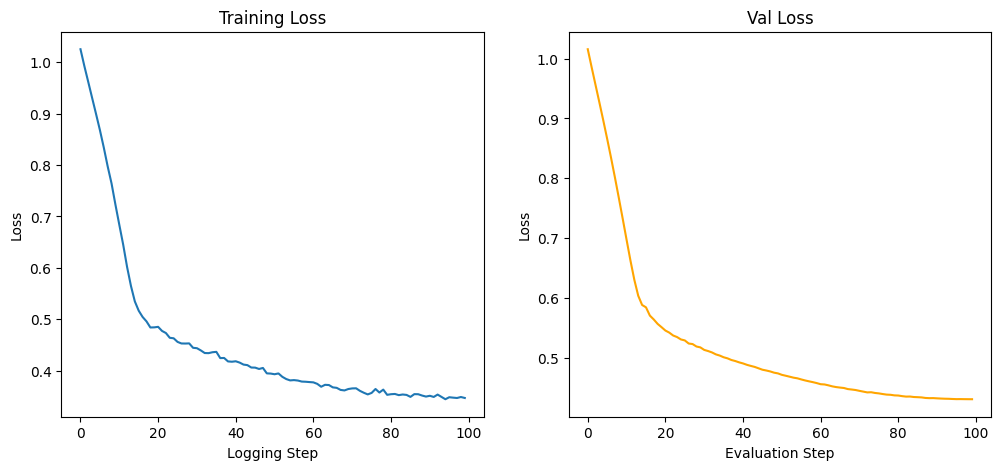

In [17]:
history = trainer.state.log_history
train_losses = [entry['loss'] for entry in history if 'loss' in entry]
val_losses = [entry['eval_loss'] for entry in history if 'eval_loss' in entry]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(train_losses)
ax[0].set_title('Training Loss')
ax[0].set_xlabel('Logging Step')
ax[0].set_ylabel('Loss')
ax[1].plot(val_losses, color='orange')
ax[1].set_title('Val Loss')
ax[1].set_xlabel('Evaluation Step')
ax[1].set_ylabel('Loss')
plt.show()

In [18]:
test_results = trainer.evaluate(eval_dataset=preprocessed_ds['test'])

print('Evaluation on test dataset')
print('Test f1: ', test_results['eval_F1-score'])

Evaluation on test dataset
Test f1:  0.3744270205066345


## 3.4. Inferrence

In [20]:
test_sentence = "The bread is top notch as well"
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model.to(device)
model.eval()

inputs = tokenizer(
    test_sentence,
    add_special_tokens=False,
    return_tensors="pt"
)

input_ids = inputs["input_ids"].to(device)

with torch.no_grad():
    outputs = model(input_ids)

    logits = outputs["logits"]

    probs = torch.nn.functional.softmax(logits, dim=-1)
    confidences, predictions = torch.max(probs, dim=-1)

In [21]:
predictions

tensor([[0, 1, 0, 0, 0, 0, 0]], device='cuda:0')

In [22]:
confidences

tensor([[0.6645, 0.4594, 0.7531, 0.7621, 0.6753, 0.7384, 0.6362]],
       device='cuda:0')

# 4. BERT

## 4.1 Tokenizer and Model

Bài này sẽ làm theo hướng tiếp cận của bài toán Name Entity Recognition (NER).

In [23]:
from transformers import AutoTokenizer, AutoModelForTokenClassification

tokenizer = AutoTokenizer.from_pretrained("distilbert/distilbert-base-uncased")
model = AutoModelForTokenClassification.from_pretrained(
    "distilbert/distilbert-base-uncased",
    num_labels=3, id2label=id2label, label2id=label2id
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForTokenClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [24]:
# BERT tokenize theo kiểu subword nên là phải đảm bảo shape của input/label trùng nhau
def tokenize_and_align_labels(examples):
    tokenized_inputs = []
    labels = []
    for tokens, tags in zip(examples['Tokens'], examples['Tags']):

        bert_tokens = []
        bert_tags = []
        for i in range(len(tokens)):
            t = tokenizer.tokenize(tokens[i])
            bert_tokens += t
            bert_tags += [int(tags[i])]*len(t)

        bert_ids = tokenizer.convert_tokens_to_ids(bert_tokens)

        tokenized_inputs.append(bert_ids)
        labels.append(bert_tags)

    return {
            'input_ids': tokenized_inputs,
            'labels': labels
        }

In [25]:
preprocessed_ds = ds.map(tokenize_and_align_labels, batched=True)

Map:   0%|          | 0/3602 [00:00<?, ? examples/s]

Map:   0%|          | 0/1119 [00:00<?, ? examples/s]

In [26]:
preprocessed_ds['train'][0]

{'Tokens': ['But', 'the', 'staff', 'was', 'so', 'horrible', 'to', 'us', '.'],
 'Tags': ['0', '0', '1', '0', '0', '0', '0', '0', '0'],
 'Polarities': ['-1', '-1', '0', '-1', '-1', '-1', '-1', '-1', '-1'],
 'input_ids': [2021, 1996, 3095, 2001, 2061, 9202, 2000, 2149, 1012],
 'labels': [0, 0, 1, 0, 0, 0, 0, 0, 0]}

## 4.2. DataCollator

In [27]:
from transformers import DataCollatorForTokenClassification

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

## 4.3. Training

In [28]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir="abte-restaurants-distilbert-base-uncased",
    logging_dir="logs",
    learning_rate=2e-5,
    per_device_train_batch_size=256,
    per_device_eval_batch_size=256,
    num_train_epochs=10,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="F1-score",
    # report_to="wandb",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=preprocessed_ds["train"],
    eval_dataset=preprocessed_ds["test"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [29]:
trainer_results = trainer.train()
save_local_checkpoint(model, 'distilbert_model', tokenizer=tokenizer)

Epoch,Training Loss,Validation Loss,F1-score
1,0.634216,0.516331,0.061774
2,0.360001,0.306354,0.525763
3,0.237012,0.262676,0.626008
4,0.190348,0.247200,0.638589
5,0.167052,0.229906,0.664330
6,0.140010,0.220393,0.701879
7,0.121104,0.216025,0.726313
8,0.110678,0.213563,0.742301
9,0.103447,0.212441,0.748454
10,0.097704,0.212309,0.754773


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved Hugging Face model to: /content/saved_models/distilbert_model


'saved_models/distilbert_model'

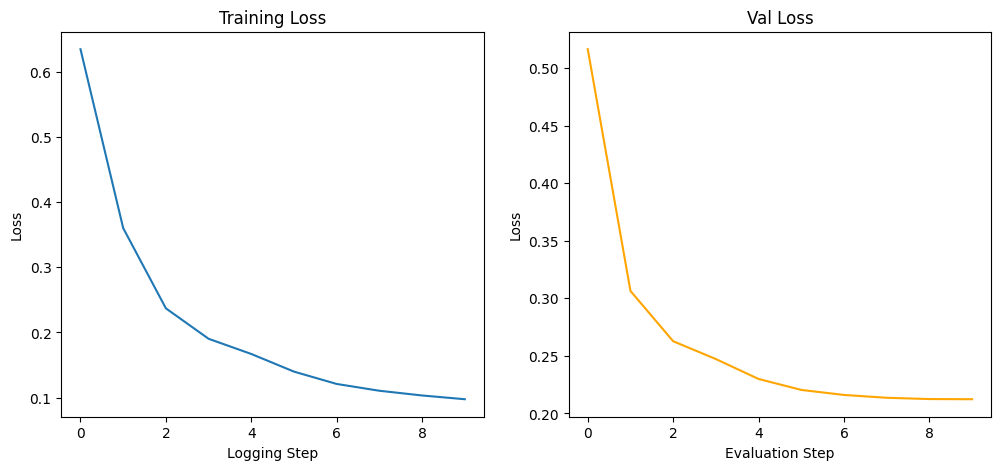

In [30]:
history = trainer.state.log_history
train_losses = [entry['loss'] for entry in history if 'loss' in entry]
val_losses = [entry['eval_loss'] for entry in history if 'eval_loss' in entry]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(train_losses)
ax[0].set_title('Training Loss')
ax[0].set_xlabel('Logging Step')
ax[0].set_ylabel('Loss')
ax[1].plot(val_losses, color='orange')
ax[1].set_title('Val Loss')
ax[1].set_xlabel('Evaluation Step')
ax[1].set_ylabel('Loss')
plt.show()

In [31]:
test_results = trainer.evaluate(eval_dataset=preprocessed_ds['test'])

print('Evaluation on val/test dataset')
print('Test f1: ', test_results['eval_F1-score'])

Evaluation on val/test dataset
Test f1:  0.7547727552654268


## 4.4. Inferrence

In [32]:
from transformers import pipeline

token_classifier = pipeline(
    task="token-classification",
    model=model,
    tokenizer=tokenizer,
    aggregation_strategy="simple"
)

In [33]:
test_sentence = 'The bread is top notch as well'
results = token_classifier(test_sentence)
results

[{'entity_group': 'Term',
  'score': np.float32(0.71180636),
  'word': 'bread',
  'start': 4,
  'end': 9}]

In [34]:
test_sentence = 'The room smells very bad'
results = token_classifier(test_sentence)
results

[{'entity_group': 'Term',
  'score': np.float32(0.56528443),
  'word': 'room',
  'start': 4,
  'end': 8}]